# RNA velocity in the Ouroboros Sphere 


It is possible to have scVelo infer RNA velocity and to output the velocity vectors onto the sphere. 

Unfourtunately scVelo is a tricky package that doesn't always play nice with other packages, so you will need a new, specific environment for this purpose. 

Also note that scVelo requires the presence of spliced and unspliced counts in your adata.layers().

For more information on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]

### Velocity environment 

**Dependencies**
- pandas
- anndata
- scvelo = 0.2.3
- scanpy = 1.8.2


To create run: 
```bash
conda create -n velocity_env python=3.10
conda activate velocity_env

mamba install -c conda-forge -c bioconda "scvelo>=0.2.3" "scanpy>=1.8.2" pandas anndata scikit-learn "numpy<1.24" "pynndescent>=0.5.13"
```

Then if you want to run this in a jupyter notebook like we do here:
```bash
mamba install -c conda-forge ipykernel
python -m ipykernel install --user --name <your_env> --display-name "Python (<your_env>)"
```


In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import scvelo as scv
import numpy as np
from sklearn.decomposition import PCA



# Step 1: Read in the dataset you have run Ouroboros on
See our Scanpy/python tutorial for earlier steps. 


In [2]:
# Read in test dataset - subsetted to existing features
adata = ad.read_h5ad('output_example/example.h5ad')

We found that cell cycle velocity comes out most cleanly when using the Ouroboros feature set, rather than with all genes as is depicted in the scVelo tutorial. This is likely because dataset may have multiple trajectories (i.e. differentiaiton and cell cycle) and focusing in on only cell cycle informative genes helps to isolate the signal from just the cell cycle. 

In [3]:
#Replace with path to your installation of Ouroboros 
ouroboros_path = '/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi'
feature_set = pd.read_csv(f'{ouroboros_path}/ouroboros/data/SHAP_feature_set.csv')
feature_set = feature_set.feature_set.tolist()

# Subset to only include feature set genes 
adata_subset = adata[:, adata.var_names.isin(feature_set)].copy()

Next read in the z_df with the latent space embeddings - is the output from Ouroboros 

In [4]:
# Replace with the path to your z_df 
z_df_path = 'output_example/ouroboros_embeddings_pseudotimes.csv'

z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,south,dormancy_pseudotime,pseudotime_phase
Unnamed: 0,,,,,,,,
CTGATCCGTCAGACTT_SRX17782706,0.509849,-0.201015,0.836449,S,0.704949,False,NaN,S
GCCCGAAAGTAGTGCG_SRX17782704,-0.625057,-0.720759,0.299685,G1,0.008879,False,NaN,G1
CCGATGGTCTGATGGT_SRX17782709,-0.292811,-0.886395,0.358562,G2M,0.945957,False,NaN,G2M
CCTCTCCGTTATGTCG_SRX17782704,-0.206861,0.711044,-0.672031,G0,NaN,True,-0.345836,Light_dormancy
AGCGTATGTCTACACA_SRX17782704,0.384594,0.881948,-0.272496,G1-G0 transition,NaN,True,-0.292188,Light_dormancy
...,...,...,...,...,...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.512673,0.460938,-0.724363,G0,NaN,True,-0.359634,Light_dormancy
ACTGTCCAGTCCTACA_SRX17782709,-0.987645,-0.029321,0.153939,G1,0.140454,False,NaN,G1
TCGCTCAAGCACTCAT_SRX17782706,-0.126240,0.891869,-0.434319,G0,NaN,True,-0.244472,Light_dormancy


ScVelo typically works on the dimensions of a UMAP embedding in adata.obsm. To make it accept the latent space instead, we just have to trick it by setting adata.obsm['X_umap'] to be our latent space instead of a UMAP embedding, and then scVelo can run as it normally would. 

In [5]:
latent_space = z_df[['dim1', 'dim2', 'dim3']].values 

# Set X_umap to be our latent space instead of a UMAP 

adata.obsm['X_umap'] = latent_space

Normalized count data: X, spliced, unspliced.


/tmp/ipykernel_1868480/3661863632.py:4: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(vel, n_neighbors = 20, use_highly_variable = False)
/projects/pangen/analysis/hmac/applications/miniconda3/envs/velocity_env/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/projects/pangen/analysis/hmac/applications/miniconda3/envs/velocity_env/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:43) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:08) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/144 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


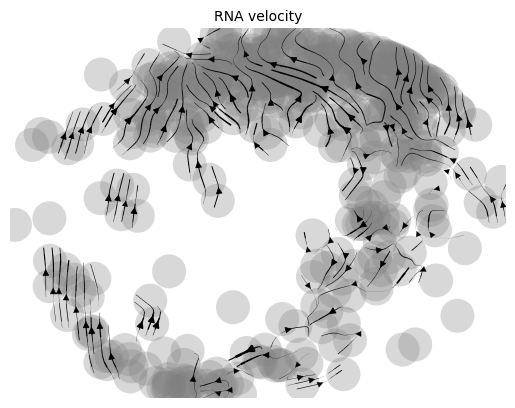

In [6]:
# Then scVelo can be run as it normally would be on the adata
## For more info on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]
vel = adata.copy()
scv.pp.moments(vel, n_neighbors = 20, use_highly_variable = False)
scv.tl.velocity(vel, mode='stochastic')
scv.tl.velocity_graph(vel)
scv.pl.velocity_embedding_stream(vel, basis='umap', title = 'RNA velocity')

We can then take the velocity vectors straight from the adata itself: 

In [7]:
vel_df = pd.DataFrame(vel.obsm['velocity_umap'], columns = ['dim1', 'dim2', 'dim3'], index = vel.obs.index)

vel_df.to_csv('output_example/example_velocity_df.csv')


We can't access Ouroboros functions like plot_sphere() here because scVelo conflicts with some of the Ouroboros dependencies. 

So, to plot these vectors onto the sphere, you can save the velocity dataframe to a csv, and load them into a new notebook using the ouroboros_env kernal. 

Here we switch to our ouroboros_env to run this code: 

In [1]:

import scanpy as sc
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs

# this is just for the tutorial rendering
from IPython.display import IFrame


In [2]:
# Read in your latent space embeddings - Replace with the path to your z_df 
z_df_path = 'output_example/ouroboros_embeddings_pseudotimes.csv' 


z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
print(z_df.head())

                                  dim1      dim2      dim3         KNN_phase  \
Unnamed: 0                                                                     
CTGATCCGTCAGACTT_SRX17782706  0.509849 -0.201015  0.836449                 S   
GCCCGAAAGTAGTGCG_SRX17782704 -0.625057 -0.720759  0.299685                G1   
CCGATGGTCTGATGGT_SRX17782709 -0.292811 -0.886395  0.358562               G2M   
CCTCTCCGTTATGTCG_SRX17782704 -0.206861  0.711044 -0.672031                G0   
AGCGTATGTCTACACA_SRX17782704  0.384594  0.881948 -0.272496  G1-G0 transition   

                              cell_cycle_pseudotime  south  \
Unnamed: 0                                                   
CTGATCCGTCAGACTT_SRX17782706               0.704949  False   
GCCCGAAAGTAGTGCG_SRX17782704               0.008879  False   
CCGATGGTCTGATGGT_SRX17782709               0.945957  False   
CCTCTCCGTTATGTCG_SRX17782704                    NaN   True   
AGCGTATGTCTACACA_SRX17782704                    NaN   True   

    

In [3]:
# Read in your velocity vectors for those embeddings 
vel_df = pd.read_csv('output_example/example_velocity_df.csv')
vel_df = vel_df.set_index('Unnamed: 0')
print(vel_df.head())

                                  dim1      dim2      dim3
Unnamed: 0                                                
CTGATCCGTCAGACTT_SRX17782706 -0.014624 -0.027485  0.004248
GCCCGAAAGTAGTGCG_SRX17782704 -0.000823  0.026368 -0.039530
CCGATGGTCTGATGGT_SRX17782709 -0.008505  0.004189 -0.013428
CCTCTCCGTTATGTCG_SRX17782704 -0.020949 -0.001416 -0.006240
AGCGTATGTCTACACA_SRX17782704 -0.037803  0.013704 -0.037323


In [4]:

# Plot the sphere as before, but give the velocity vector df to the parameter velocity to have it plot the vectors too 
fig = obo.plot_sphere(z_df, colour_by='KNN_phase', velocity=vel_df, show=False, savefig = 'output_example/example_sphere_with_velocity.html')
IFrame(src="../output_example/example_sphere_with_velocity.html", width="100%", height=600)


We can also plot RNA velocity vectors on the robinson/map projection.
    * sometimes the scale of the arrows gets funky so you may have to adjust the 'scale' parameter

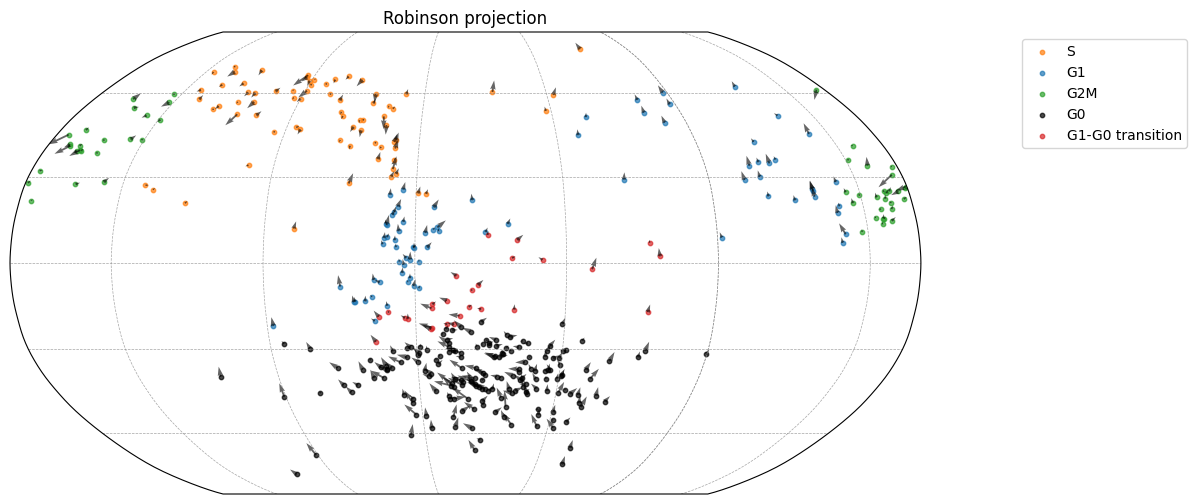

In [5]:
obo.plot_robinson_projection(
    z_df, 
    colour_by = 'KNN_phase',
    velocity_df=vel_df, 
    palette=None, 
    ref=None,
    central_longitude=80, 
    title="Robinson projection", 
    alpha=0.7,
    scale=3
    
)